## 1. Import Libraries

In [1]:


import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load Dataset

In [2]:

test_data = pd.read_csv("cs-test.csv")
train_data = pd.read_csv("cs-training.csv")

## 3. Exploratory Data Analysis (EDA)

In [3]:
test_data.sample(10)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
47350,47351,NaN,0.427910,54,0,0.189906,11868.0,10,0,1,0,4.0
40229,40230,NaN,0.380695,62,0,1296.000000,NaN,8,1,1,0,0.0
38484,38485,NaN,0.395261,40,1,0.439665,13250.0,10,0,2,0,2.0
78119,78120,NaN,0.268121,49,0,0.299560,7500.0,6,0,2,0,3.0
52612,52613,NaN,0.213664,69,4,0.412397,13583.0,18,0,3,0,0.0
8411,8412,NaN,0.552825,48,0,0.230518,15000.0,11,0,2,0,0.0
39221,39222,NaN,0.734884,44,0,0.642647,33000.0,23,0,8,0,0.0
70302,70303,NaN,0.004414,56,2,0.219621,8500.0,13,0,2,0,3.0
43992,43993,NaN,0.027890,72,0,0.361410,4000.0,8,0,2,0,0.0
13139,13140,NaN,0.004250,57,0,0.364244,5833.0,6,0,2,0,2.0


In [4]:
#Let's take a look at the data
train_data.sample(10)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
124773,124774,0,0.569095,37,0,1150.000000,NaN,5,0,1,0,0.0
5376,5377,0,0.992934,29,0,0.201545,4400.0,5,0,1,1,0.0
144571,144572,0,0.369894,63,0,0.852215,7334.0,7,0,2,0,0.0
33925,33926,0,0.884052,29,0,0.779475,1636.0,9,0,0,0,0.0
20586,20587,0,0.036408,42,1,0.527291,6100.0,8,0,1,0,3.0
88442,88443,0,0.187714,33,0,0.340909,6687.0,10,0,1,0,2.0
146059,146060,0,0.030363,55,0,1557.000000,NaN,6,0,1,0,1.0
113163,113164,0,0.044459,67,1,0.154615,9500.0,7,0,1,0,0.0
21465,21466,0,0.090977,56,0,1351.000000,NaN,6,0,1,0,1.0
106752,106753,0,0.865296,27,0,0.094607,7916.0,7,0,0,0,0.0


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

We have large null values for MonthlyIncome and NumberOfDependents, we will handle those values in a bit. Also, these features has inconsistent data types, we will change them to int64. Let's look at the summary statistics of the features.

In [6]:
train_data.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Identified an invalid age value (0) and replaced it with the median age to improve data quality. Examined potentially redundant features, including past-due payment variables and loan-related attributes, using a correlation matrix to understand their relationships and support feature selection. Finally, reviewed the test dataset to ensure consistency before model training.


In [7]:
test_data.sample(10)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
46065,46066,NaN,1.000000,55,2,0.065696,3500.0,6,6,0,4,0.0
100517,100518,NaN,0.250173,31,0,0.393786,3958.0,8,0,1,0,0.0
60833,60834,NaN,0.874650,56,0,0.369817,9309.0,8,0,3,0,0.0
23167,23168,NaN,0.067115,67,0,300.000000,NaN,5,0,1,0,NaN
3743,3744,NaN,0.031750,81,0,0.449191,5500.0,9,0,1,0,0.0
101087,101088,NaN,0.015712,42,0,0.163378,3800.0,4,0,0,0,0.0
82542,82543,NaN,1.000000,36,0,0.025273,2017.0,2,0,0,0,0.0
80554,80555,NaN,0.666368,41,1,1.434757,3417.0,16,0,2,0,0.0
97483,97484,NaN,0.045898,74,0,0.152508,6838.0,13,0,1,0,0.0
56318,56319,NaN,0.093920,69,0,0.132083,10500.0,17,0,1,0,0.0


In [8]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            101503 non-null  int64  
 1   SeriousDlqin2yrs                      0 non-null       float64
 2   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 3   age                                   101503 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 5   DebtRatio                             101503 non-null  float64
 6   MonthlyIncome                         81400 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 8   NumberOfTimes90DaysLate               101503 non-null  int64  
 9   NumberRealEstateLoansOrLines          101503 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 11  

In [9]:
test_data.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,101503.000000,0.0,101503.000000,101503.000000,101503.000000,101503.000000,8.140000e+04,101503.000000,101503.000000,101503.000000,101503.000000,98877.000000
mean,50752.000000,NaN,5.310000,52.405436,0.453770,344.475020,6.855036e+03,8.453514,0.296691,1.013074,0.270317,0.769046
std,29301.536524,NaN,196.156039,14.779756,4.538487,1632.595231,3.650860e+04,5.144100,4.515859,1.110253,4.503578,1.136778
min,1.000000,NaN,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25376.500000,NaN,0.030131,41.000000,0.000000,0.173423,3.408000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,50752.000000,NaN,0.152586,52.000000,0.000000,0.364260,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,76127.500000,NaN,0.564225,63.000000,0.000000,0.851619,8.200000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,101503.000000,NaN,21821.000000,104.000000,98.000000,268326.000000,7.727000e+06,85.000000,98.000000,37.000000,98.000000,43.000000


The test dataset showed no invalid age values, with a minimum age of 21. Missing values were identified in the MonthlyIncome and NumberOfDependents features and handled using the same preprocessing strategy as the training data. The target column (SeriousDlqin2yrs) contains only 0 values, as expected for the test dataset.

Let's dive into the data preprocessing and exploratory analysis to prepare the dataset for model development.

First, we will look at the distribution of our target class. SeriousDlqin2yrs to have some perspective about the problem.

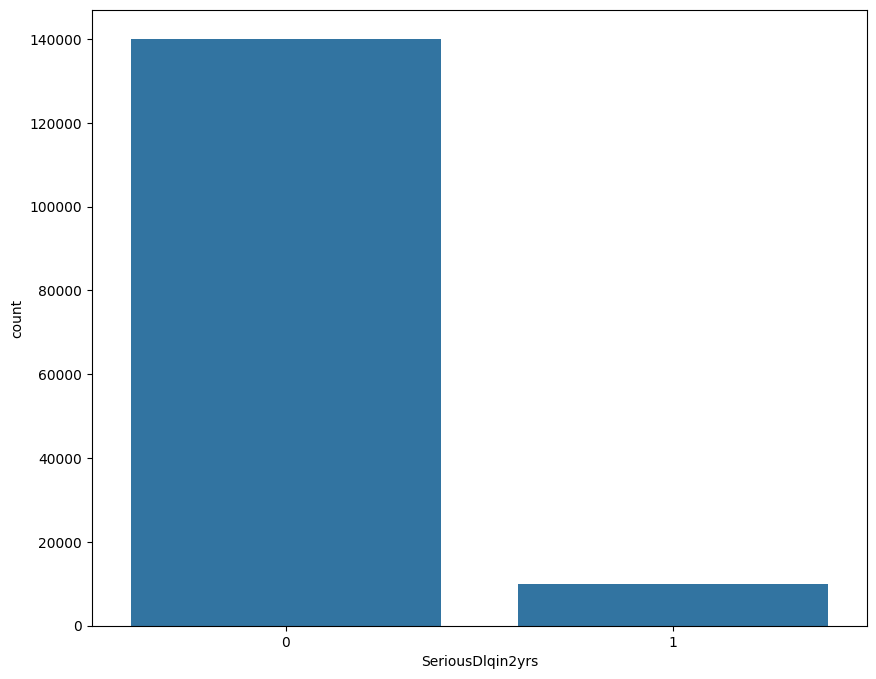

In [10]:
plt.figure(figsize=(10,8))
sns.countplot(data=train_data, x="SeriousDlqin2yrs")
plt.show()

There is clear problem here, we have an **unbalanced target class!!** we will check the event rate of financial distress (SeriousDlqin2yrs) in our dataset.

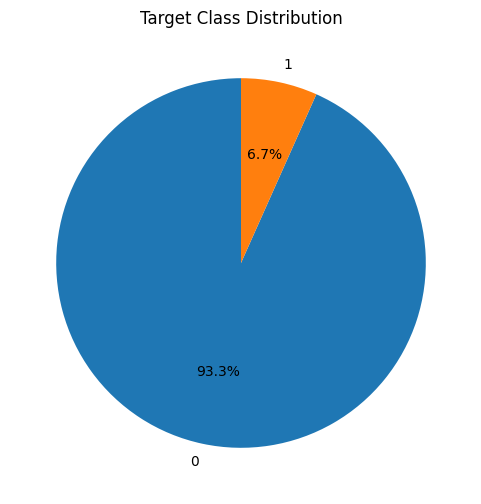

In [11]:
train_data["SeriousDlqin2yrs"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    figsize=(6,6)
)

plt.title("Target Class Distribution")
plt.ylabel("")
plt.show()

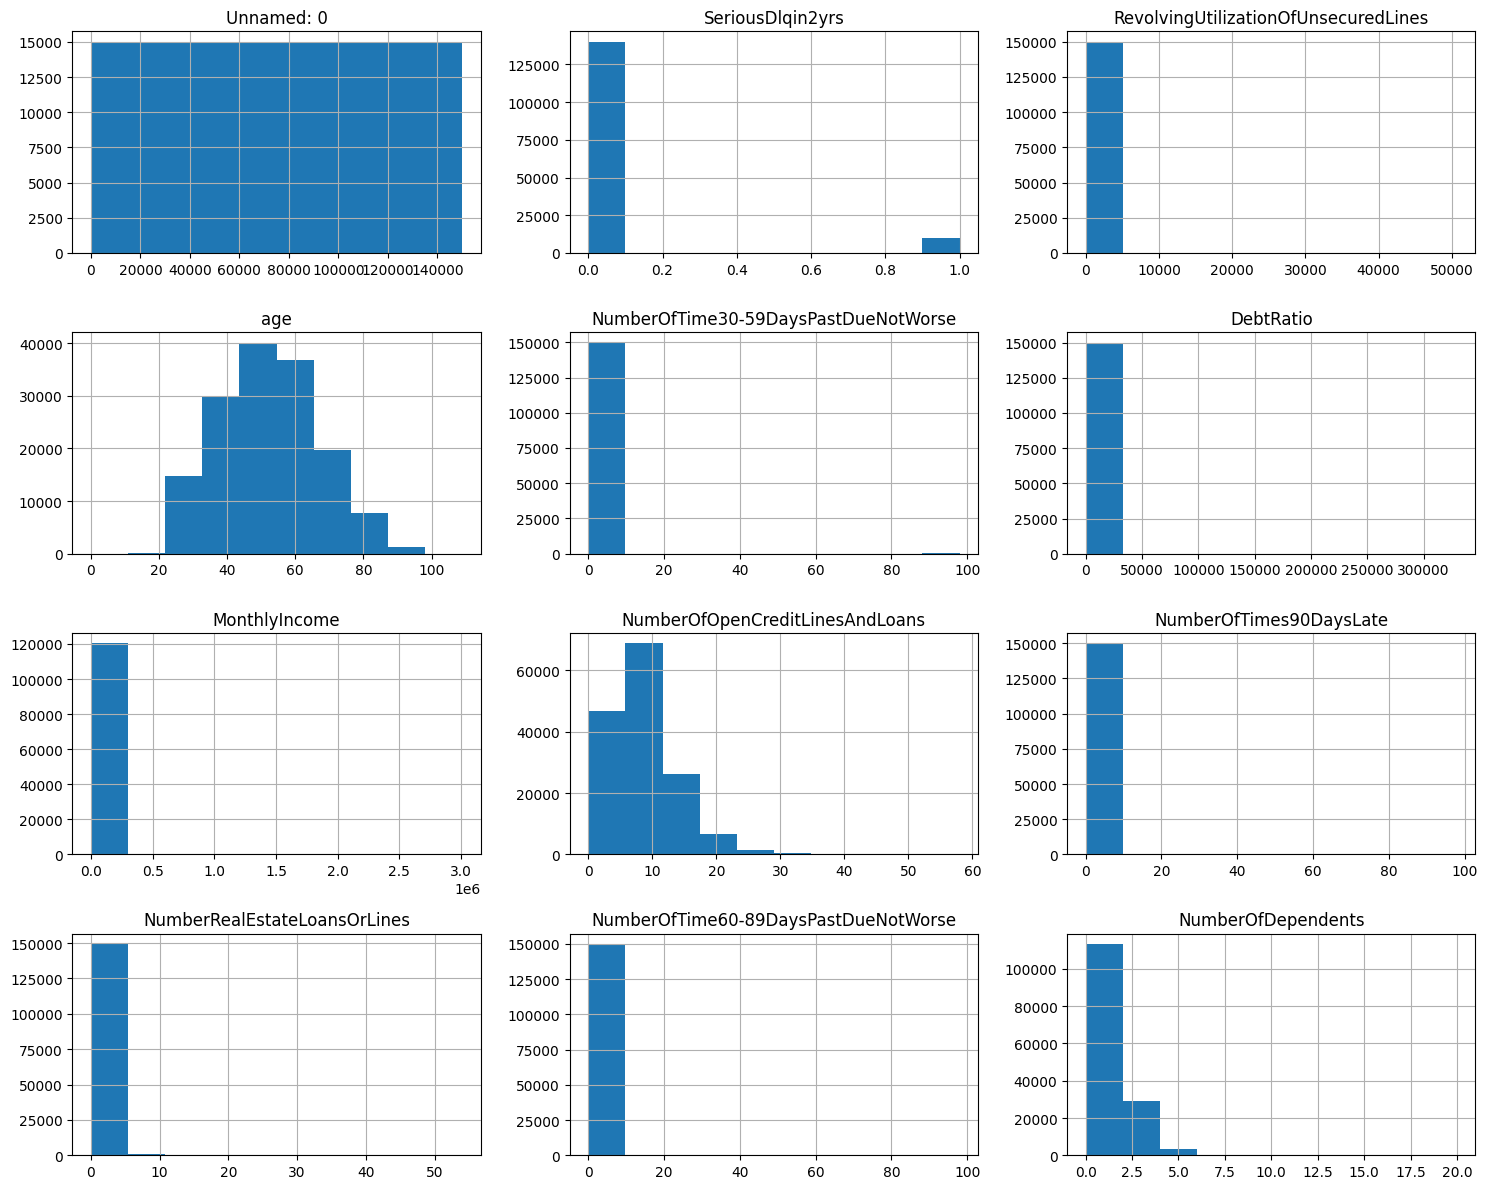

In [12]:
train_data.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

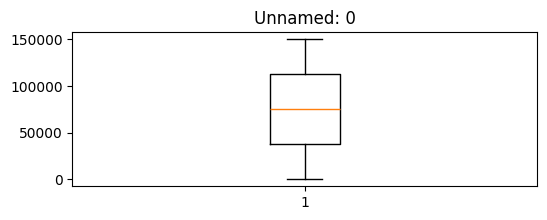

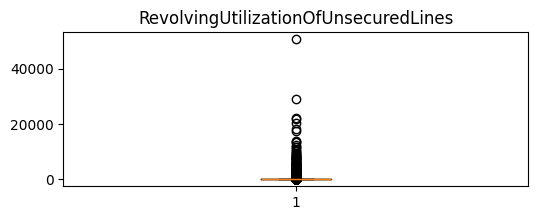

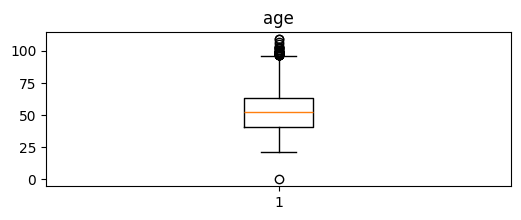

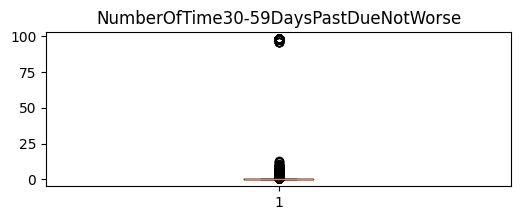

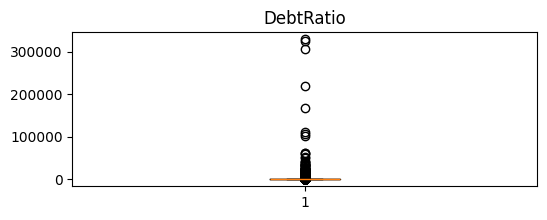

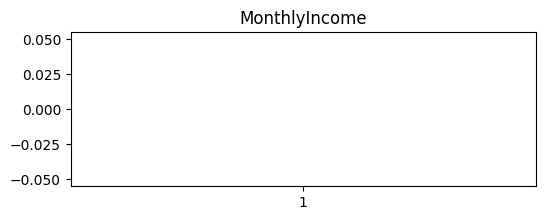

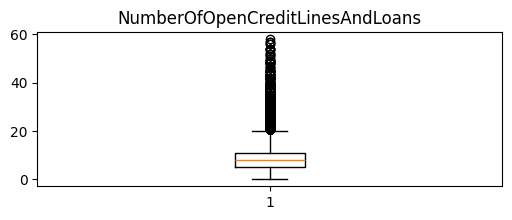

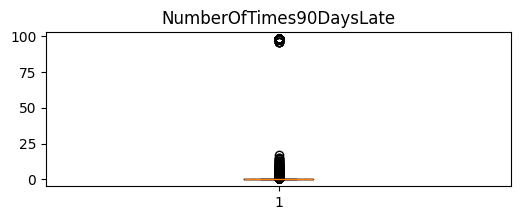

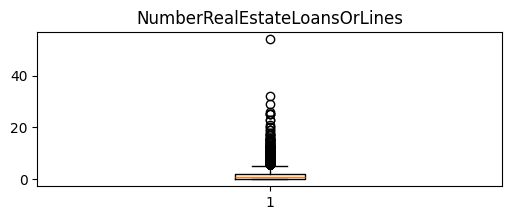

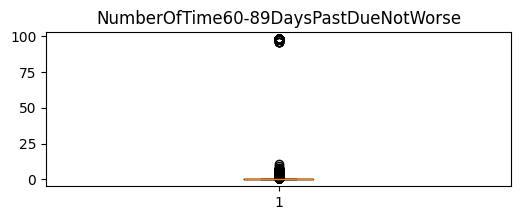

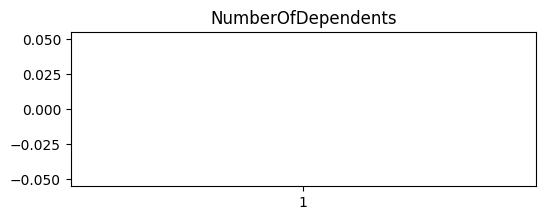

In [13]:
for col in train_data.columns:

    if col!="SeriousDlqin2yrs":

        plt.figure(figsize=(6,2))

        plt.boxplot(train_data[col])

        plt.title(col)

        plt.show()

In [14]:
class_0 = train_data.SeriousDlqin2yrs.value_counts()[0]
class_1 = train_data.SeriousDlqin2yrs.value_counts()[1]
print("Total number of class_0: {}".format(class_0))
print("Total number of class_1: {}".format(class_1))
print("Event rate: {} %".format(class_1/(class_0+class_1) *100))

Total number of class_0: 139974
Total number of class_1: 10026
Event rate: 6.683999999999999 %


The target variable is highly imbalanced, with only 6.68% positive cases. To prevent the model from being biased toward the majority class, the project focuses on optimizing ROC-AUC, the competition's evaluation metric, rather than accuracy. The following strategies were applied to address class imbalance:

•⁠  ⁠Random Under-Sampling (RUS) to balance the majority and minority classes.
•⁠  ⁠Class-weighted/Penalized models to reduce bias toward the majority class.
•⁠  ⁠Ensemble learning algorithms, including Random Forest and Gradient Boosting, to improve predictive performance on imbalanced data.


Back to the training set.
age feature has a 0 value in it, so we will locate the entry and impute it with the age median.

## 4. Data Cleaning and Handling

In [15]:
train_data.loc[train_data["age"] < 18] #less than legal age

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


only one instance, let's impute it right away.

In [16]:
train_data.loc[train_data["age"] == 0, "age"] = train_data.age.median()

We're done with the age feature, now we will go and impute missing values for the MonthlyIncome feature. We will tackle this differently by bracketing ages with the working (18 to 60) and senior (60 and above). First, let's create a temporary dataframes for them and compute for each's median then impute the values accordingly.

In [17]:
age_working = train_data.loc[(train_data["age"] >= 18) & (train_data["age"] < 60)]
age_senior = train_data.loc[(train_data["age"] >= 60)]

age_working_impute = age_working.MonthlyIncome.mean()
age_senior_impute = age_senior.MonthlyIncome.mean()

We will change the monthlyincome data type to int64 then fill those null values with 99999 and impute with the corresponding age's monthlyincome mean.

In [18]:
train_data["MonthlyIncome"] = np.absolute(train_data["MonthlyIncome"])

In [19]:
train_data["MonthlyIncome"] = train_data["MonthlyIncome"].fillna(99999)

In [20]:
train_data["MonthlyIncome"] = train_data["MonthlyIncome"].astype('int64')

In [21]:
train_data.loc[((train_data["age"] >= 18) & (train_data["age"] < 60)) & (train_data["MonthlyIncome"] == 99999),\
               "MonthlyIncome"] = age_working_impute
train_data.loc[(train_data["age"] >= 60) & (train_data["MonthlyIncome"] == 99999), "MonthlyIncome"] = age_senior_impute

/var/folders/2d/4fjrdsbn2599c0gm85x8pljr0000gn/T/ipykernel_3242/2410769817.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6638.484232804233' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_data.loc[((train_data["age"] >= 18) & (train_data["age"] < 60)) & (train_data["MonthlyIncome"] == 99999),\


In [22]:
#check
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         150000 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [23]:
train_data.loc[train_data["MonthlyIncome"] == 99999]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents


We're done with the Monthly Income, now we will move to the NumberOfDependents feature.

In [24]:
train_data["NumberOfDependents"] = np.absolute(train_data["NumberOfDependents"])
train_data["NumberOfDependents"] = train_data["NumberOfDependents"].fillna(0)
train_data["NumberOfDependents"] = train_data["NumberOfDependents"].astype('int64')

In [25]:
train_data.NumberOfDependents.value_counts()

NumberOfDependents
0     90826
1     26316
2     19522
3      9483
4      2862
5       746
6       158
7        51
8        24
10        5
9         5
20        1
13        1
Name: count, dtype: int64

I decided not to go through each of the numberofdependents feature and impute it by the mode. We will now take a look at the correlation of the features to the target variable.

<Axes: >

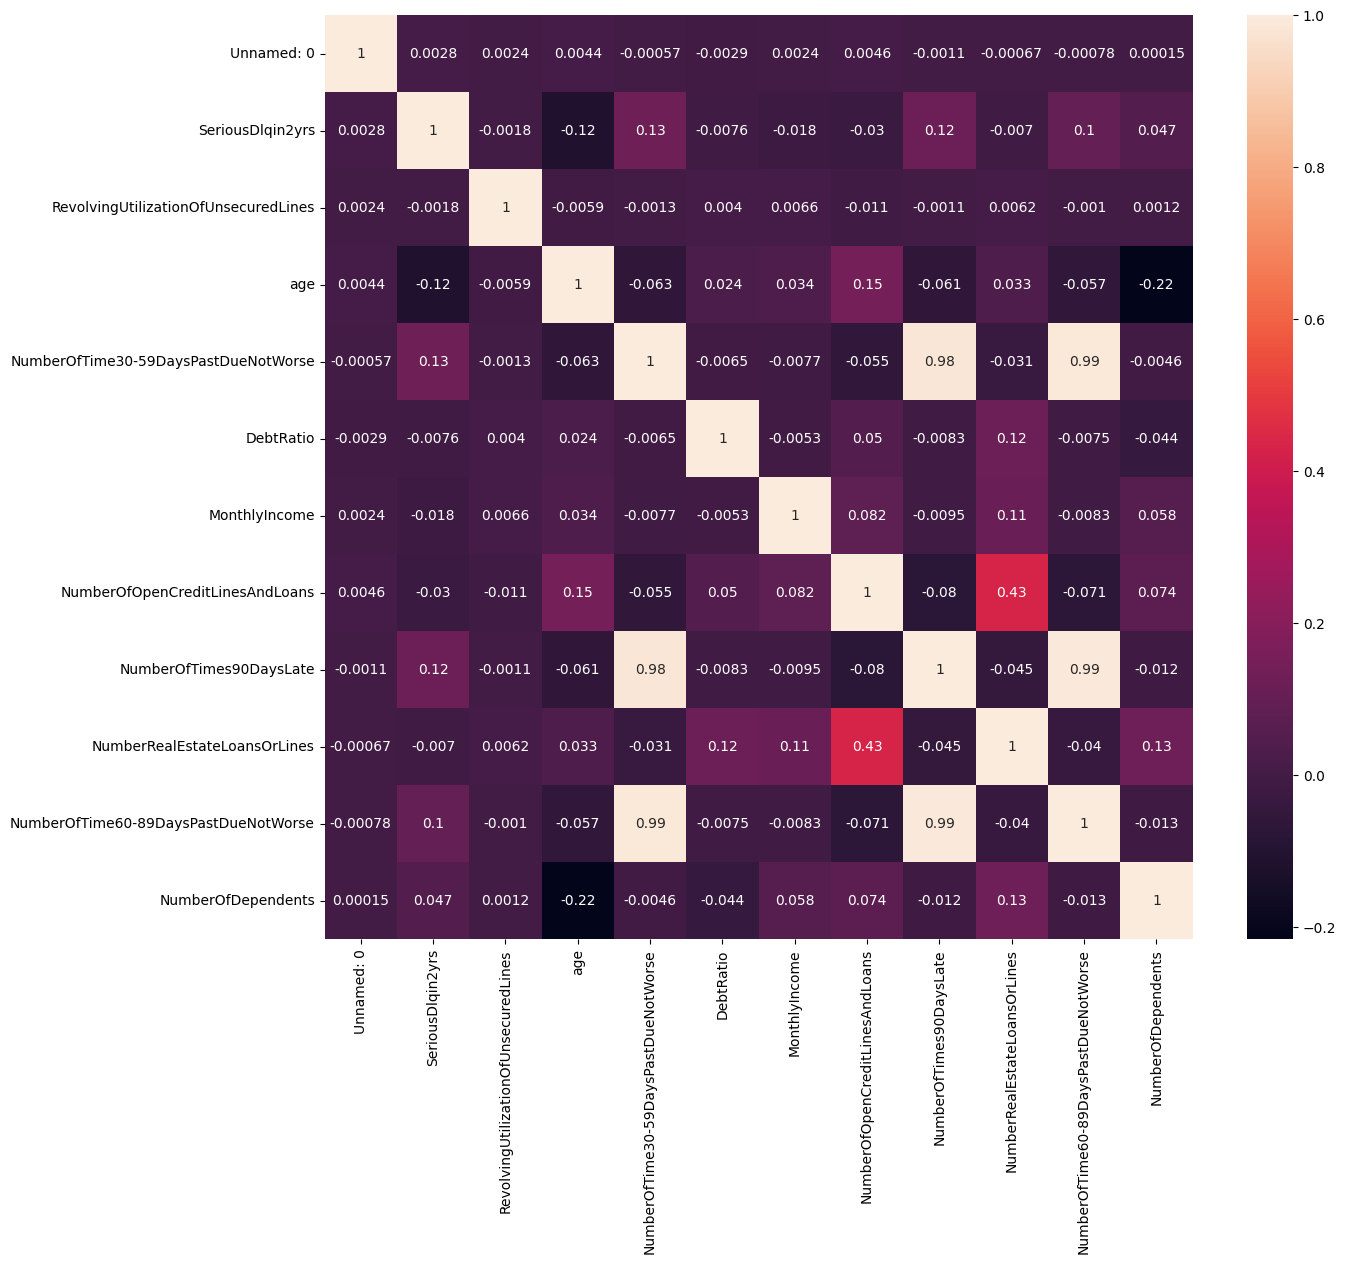

In [26]:
corr = train_data.corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=True, fmt=".2g")

**Findings**: Correlation analysis revealed strong multicollinearity among the past-due payment features (NumberOfTimes90DaysLate, NumberOfTime60-89DaysPastDueNotWorse, and NumberOfTime30-59DaysPastDueNotWorse). To reduce redundancy, these features were combined into a single feature representing the borrower's overall late payment history. Similarly, the relationship between NumberOfOpenCreditLinesAndLoans and NumberRealEstateLoansOrLines was analyzed, and appropriate feature engineering was applied to capture their predictive information while minimizing multicollinearity.

To reduce feature redundancy and improve model performance, the past-due payment variables were merged into a single feature representing a customer's overall payment default history. Similarly, the credit and loan-related features were combined to capture total borrowing exposure while preserving relevant financial information.

## 5. Feature Engineering

In [27]:
train_data["CombinedDefaulted"] = (train_data["NumberOfTimes90DaysLate"] + train_data["NumberOfTime60-89DaysPastDueNotWorse"])\
                                        + train_data["NumberOfTime30-59DaysPastDueNotWorse"]

In [28]:
train_data.loc[(train_data["CombinedDefaulted"] >= 1), "CombinedDefaulted"] = 1

In [29]:
train_data["CombinedCreditLoans"] = train_data["NumberOfOpenCreditLinesAndLoans"] + \
                                        train_data["NumberRealEstateLoansOrLines"]

In [30]:
train_data.loc[(train_data["CombinedCreditLoans"] <= 5), "CombinedCreditLoans"] = 0
train_data.loc[(train_data["CombinedCreditLoans"] > 5), "CombinedCreditLoans"] = 1

In [31]:
train_data.CombinedCreditLoans.value_counts()

CombinedCreditLoans
1    111375
0     38625
Name: count, dtype: int64

Next, we will create a binary feature WithDependents which is derived from the NumberOfDependents feature. Also, from the description of the data DebtRatio = Monthly debt payments / monthly gross income. we will extract MonthlyDebtPayments from this formula to get a new feature.

In [32]:
train_data["WithDependents"] = train_data["NumberOfDependents"]
train_data.loc[(train_data["WithDependents"] >= 1), "WithDependents"] = 1

In [33]:
train_data.WithDependents.value_counts()

WithDependents
0    90826
1    59174
Name: count, dtype: int64

In [34]:
train_data["MonthlyDebtPayments"] = train_data["DebtRatio"] * train_data["MonthlyIncome"]
train_data["MonthlyDebtPayments"] = np.absolute(train_data["MonthlyDebtPayments"])
train_data["MonthlyDebtPayments"] = train_data["MonthlyDebtPayments"].astype('int64')

In [35]:
train_data["age"] = train_data["age"].astype('int64')
train_data["MonthlyIncome"] = train_data["MonthlyIncome"].astype('int64')

Also, let's see if we can get a good predictor out of age feature. using senior and working temporary dataframes earlier.

In [36]:
train_data["age_map"] = train_data["age"]
train_data.loc[(train_data["age"] >= 18) & (train_data["age"] < 60), "age_map"] = 1
train_data.loc[(train_data["age"] >= 60), "age_map"] = 0 

In [37]:
#replacing those numbers to categorical features then get the dummy variables
train_data["age_map"] = train_data["age_map"].replace(0, "working")
train_data["age_map"] = train_data["age_map"].replace(1, "senior")

In [38]:
train_data = pd.concat([train_data, pd.get_dummies(train_data.age_map,prefix='is')], axis=1)

Now let's look at the correlation matrix to decide to retain or drop the engineered features (avoiding multicollinearity).

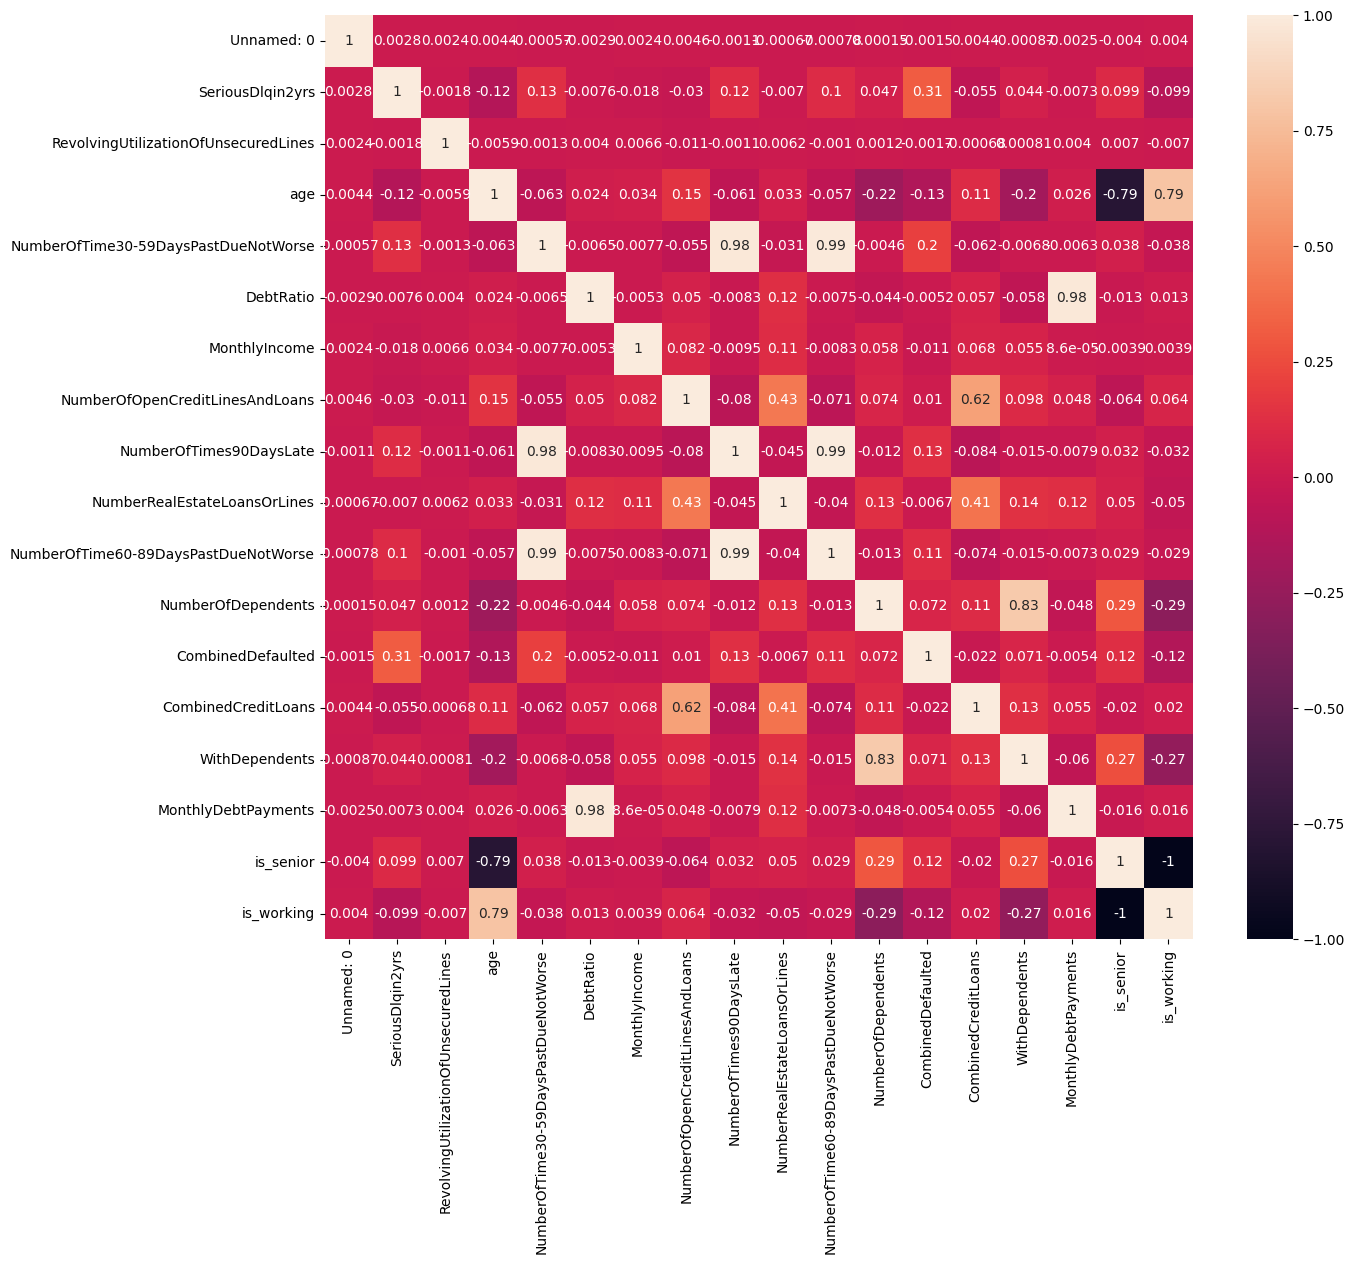

In [39]:
corr = train_data.corr(numeric_only=True)

plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=True, fmt=".2g")
plt.show()

Findings: 
* we will retain CombinedDefaulted feature as it clearly a good predictor of our target class than the three features it was derived from.
* we will retain NumberOfTime30-59DaysPastDueNotWorse and drop the other two features derived from CombinedDefaulted as it gives a more meaningful information on our target variable (also, it looks like this is the medium range of time a borrower defaulted a payment)
* we will drop the engineered is_working and is_senior feature since age feature outperforms them.
* we will drop also the WithDependents
* we will retain CombinedCreditLoans also since it outperforms the two features it came from.
* we will drop MonthlyDebtPayments


In [40]:
train_data.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'CombinedDefaulted', 'CombinedCreditLoans',
       'WithDependents', 'MonthlyDebtPayments', 'age_map', 'is_senior',
       'is_working'],
      dtype='object')

In [41]:
train_data.drop(["Unnamed: 0","NumberOfOpenCreditLinesAndLoans",\
                 "NumberOfTimes90DaysLate","NumberRealEstateLoansOrLines","NumberOfTime60-89DaysPastDueNotWorse",\
                 "WithDependents","age_map","is_senior","is_working", "MonthlyDebtPayments"], axis=1, inplace=True)

In [42]:
train_data.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfDependents', 'CombinedDefaulted', 'CombinedCreditLoans'],
      dtype='object')

<Axes: >

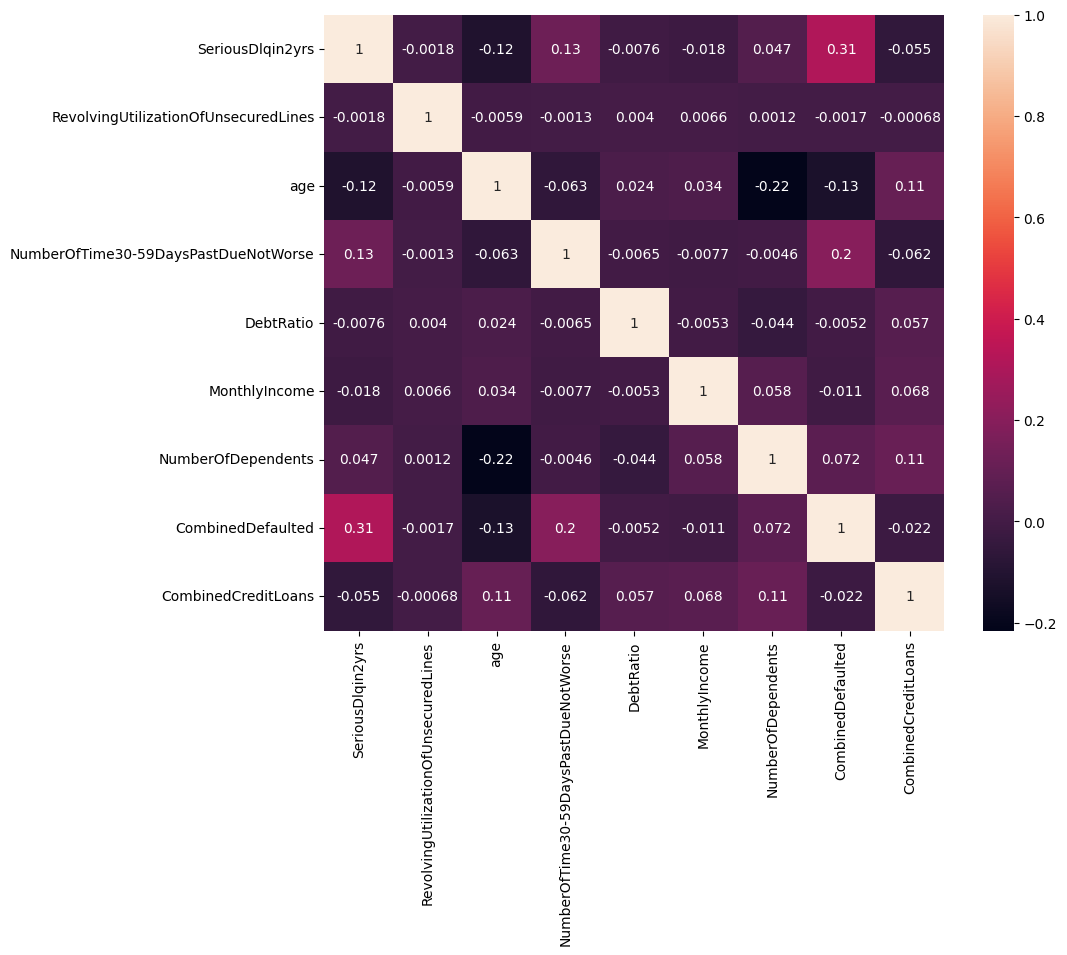

In [43]:
#now let's take a look at the filtered final features to be used in predicting the financial distress for the next two years
corr = train_data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2g")

After completing data cleaning and feature engineering, the training dataset was ready for model development. Since the target variable remained highly imbalanced, class imbalance handling techniques such as Random Under-Sampling (RUS) and class-weighted (penalized) models were applied before training to improve the model's ability to generalize to unseen data.

Now let's also clean the test set! Since we have concluded what features to retain and drop. we will skip some of the process.

In [44]:
def cleaned_dataset(dataset):
    dataset.loc[dataset["age"] <= 18, "age"] = dataset.age.median()
    
    age_working = dataset.loc[(dataset["age"] >= 18) & (dataset["age"] < 60)]
    age_senior = dataset.loc[(dataset["age"] >= 60)]

    age_working_impute = age_working.MonthlyIncome.mean()
    age_senior_impute = age_senior.MonthlyIncome.mean()

    dataset["MonthlyIncome"] = np.absolute(dataset["MonthlyIncome"])
    dataset["MonthlyIncome"] = dataset["MonthlyIncome"].fillna(99999)
    dataset["MonthlyIncome"] = dataset["MonthlyIncome"].astype('int64')

    dataset.loc[((dataset["age"] >= 18) & (dataset["age"] < 60)) & (dataset["MonthlyIncome"] == 99999),\
                   "MonthlyIncome"] = age_working_impute
    dataset.loc[(train_data["age"] >= 60) & (dataset["MonthlyIncome"] == 99999), "MonthlyIncome"] = age_senior_impute
    dataset["NumberOfDependents"] = np.absolute(dataset["NumberOfDependents"])
    dataset["NumberOfDependents"] = dataset["NumberOfDependents"].fillna(0)
    dataset["NumberOfDependents"] = dataset["NumberOfDependents"].astype('int64')

    dataset["CombinedDefaulted"] = (dataset["NumberOfTimes90DaysLate"] + dataset["NumberOfTime60-89DaysPastDueNotWorse"])\
                                            + dataset["NumberOfTime30-59DaysPastDueNotWorse"]

    dataset.loc[(dataset["CombinedDefaulted"] >= 1), "CombinedDefaulted"] = 1

    dataset["CombinedCreditLoans"] = dataset["NumberOfOpenCreditLinesAndLoans"] + \
                                            dataset["NumberRealEstateLoansOrLines"]
    dataset.loc[(dataset["CombinedCreditLoans"] <= 5), "CombinedCreditLoans"] = 0
    dataset.loc[(dataset["CombinedCreditLoans"] > 5), "CombinedCreditLoans"] = 1

    dataset.drop(["Unnamed: 0","NumberOfOpenCreditLinesAndLoans",\
                 "NumberOfTimes90DaysLate","NumberRealEstateLoansOrLines","NumberOfTime60-89DaysPastDueNotWorse"], axis=1, inplace=True)

cleaned_dataset(test_data)

/var/folders/2d/4fjrdsbn2599c0gm85x8pljr0000gn/T/ipykernel_3242/2823152905.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6596.628562971217' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataset.loc[((dataset["age"] >= 18) & (dataset["age"] < 60)) & (dataset["MonthlyIncome"] == 99999),\


In [45]:
test_data.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfDependents', 'CombinedDefaulted', 'CombinedCreditLoans'],
      dtype='object')

In [46]:
train_data.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfDependents', 'CombinedDefaulted', 'CombinedCreditLoans'],
      dtype='object')

In [47]:
train_data.shape, test_data.shape

((150000, 9), (101503, 9))

In [48]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 9 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      0 non-null       float64
 1   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 2   age                                   101503 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 4   DebtRatio                             101503 non-null  float64
 5   MonthlyIncome                         101503 non-null  float64
 6   NumberOfDependents                    101503 non-null  int64  
 7   CombinedDefaulted                     101503 non-null  int64  
 8   CombinedCreditLoans                   101503 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 7.0 MB


## 6. Feature Selection

In [49]:
#Let's split our predictors and the target variable in our datasets
X = train_data.drop("SeriousDlqin2yrs", axis=1).copy()
y = train_data.SeriousDlqin2yrs
X.shape, y.shape

((150000, 8), (150000,))

In [50]:
X_test = test_data.drop("SeriousDlqin2yrs", axis=1).copy()
y_test = test_data.SeriousDlqin2yrs
X_test.shape, y_test.shape

((101503, 8), (101503,))

In [51]:
#let's first try the penalized model Logit by providing the class_weight="balanced" parameter
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_predict #to perform stratified sampling using cv param
from sklearn.metrics import roc_curve, roc_auc_score #AUC score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
logit = LogisticRegression(random_state=42, solver="saga", penalty="l1", class_weight="balanced", C=1.0, max_iter=500)
scaler = StandardScaler().fit(X_train)

In [52]:
X_train_scaled = scaler.transform(X_train) #scaling features!
X_val_scaled = scaler.transform(X_val)

In [53]:
logit.fit(X_train_scaled, y_train)
logit_scores_proba = logit.predict_proba(X_train_scaled)
logit_scores = logit_scores_proba[:,1]

In [54]:
#lets make a roc_curve visualization
def plot_roc_curve(fpr, tpr, label=None):
    plt.figure(figsize=(12,10))
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0,1],[0,1], "k--")
    plt.axis([0,1,0,1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive rate")

AUC Score 0.8013443396819069


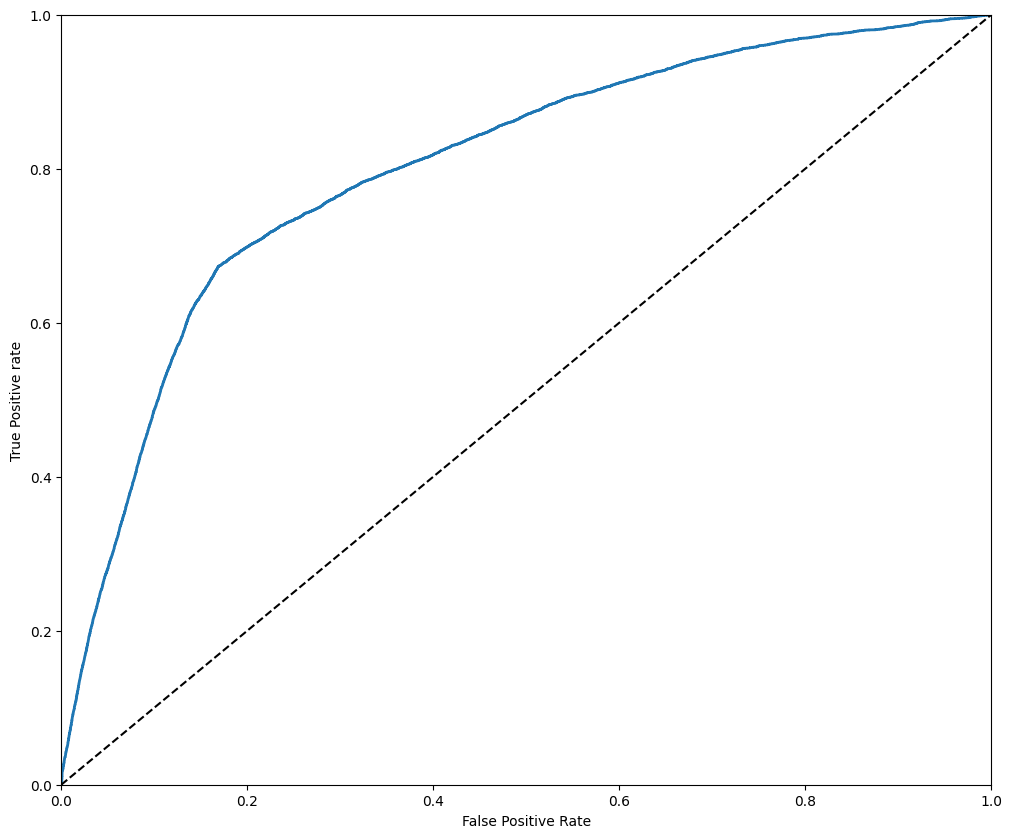

In [55]:
fpr_logit, tpr_logit, thresh_logit = roc_curve(y_train, logit_scores)
plot_roc_curve(fpr_logit,tpr_logit)
print("AUC Score {}".format(roc_auc_score(y_train,logit_scores)))

AUC Score 0.8102686309765861


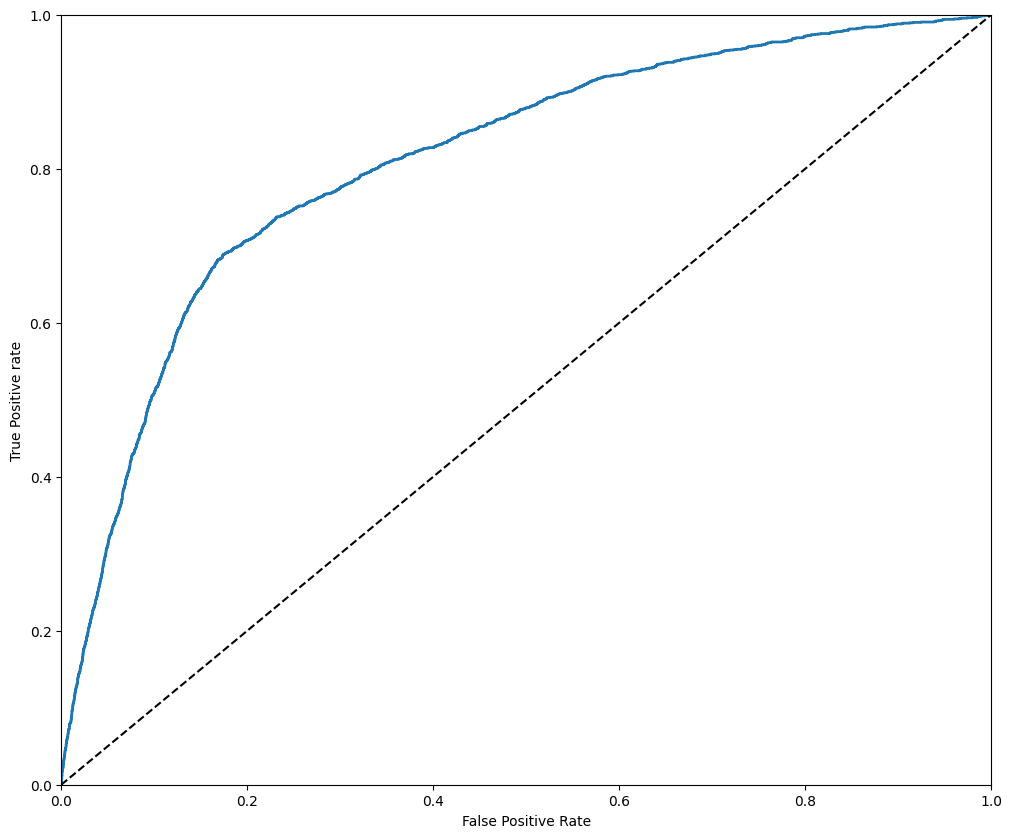

In [56]:
#validate with the validation set
logit_scores_proba_val = logit.predict_proba(X_val_scaled)
logit_scores_val = logit_scores_proba_val[:,1]
fpr_logit_val, tpr_logit_val, thresh_logit_val = roc_curve(y_val, logit_scores_val)
plot_roc_curve(fpr_logit_val,tpr_logit_val)
print("AUC Score {}".format(roc_auc_score(y_val,logit_scores_val)))

In [57]:
logit_C_low = LogisticRegression(random_state=42, solver="saga", penalty="l1", class_weight="balanced", C=0.001, max_iter=1000)
logit_C_low.fit(X_train_scaled, y_train)
logit_C_low_scores_proba = logit_C_low.predict_proba(X_train_scaled)
logit_C_low_scores = logit_C_low_scores_proba[:,1]
fpr_logit_C_low, tpr_logit_C_low, thresh_logit_C_low = roc_curve(y_train, logit_C_low_scores)
#plot_roc_curve(fpr_logit_C_low,tpr_logit_C_low)
print("AUC Score {}".format(roc_auc_score(y_train,logit_C_low_scores)))

AUC Score 0.800146303947209


In [58]:
logit_C_high = LogisticRegression(random_state=42, solver="saga", penalty="l1", class_weight="balanced", C=1000, max_iter=1000)
logit_C_high.fit(X_train_scaled, y_train)
logit_C_high_scores_proba = logit_C_high.predict_proba(X_train_scaled)
logit_C_high_scores = logit_C_high_scores_proba[:,1]
fpr_logit_C_high, tpr_logit_C_high, thresh_logit_C_high = roc_curve(y_train, logit_C_high_scores)
print("AUC Score {}".format(roc_auc_score(y_train,logit_C_high_scores)))

AUC Score 0.8013458260150584


Text(0, 0.5, 'True Positive rate')

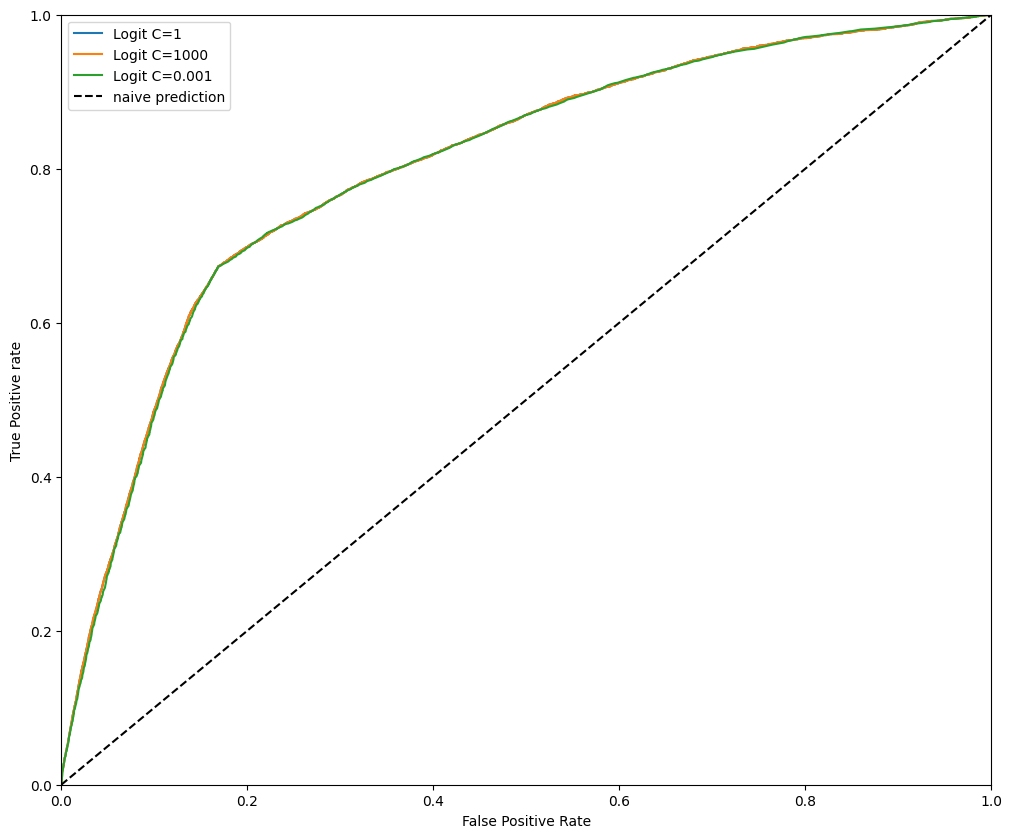

In [59]:
#lets make a roc_curve visualization
plt.figure(figsize=(12,10))
plt.plot(fpr_logit, tpr_logit, label="Logit C=1")
plt.plot(fpr_logit_C_high, tpr_logit_C_high , label="Logit C=1000")
plt.plot(fpr_logit_C_low, tpr_logit_C_low , label="Logit C=0.001")
plt.plot([0,1],[0,1], "k--", label="naive prediction")
plt.axis([0,1,0,1])
plt.legend(loc="best")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive rate")

## 7. Handling Imbalanced Dataset

Adjusting the C parameter don't mean much for our classifier to improve it's score. Let's try our second option which is to implement undersampling of our dataset to make the target variable balanced.

In [60]:
#Random Sampling
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
print("Original dataset shape {}".format(Counter(y)))

Original dataset shape Counter({0: 139974, 1: 10026})


In [61]:
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X,y)
print("Resampled dataset shape {}".format(Counter(y_resampled)))

Resampled dataset shape Counter({0: 10026, 1: 10026})


From here, we dropped most of the majority class ended up on a 50/50 ratio. the disadvantage of this strategy is that have lost most of the information from the majority class. advantage are our dataset will have a faster training and we solved the unbalanced dataset problem. let's give it a try!

In [62]:
X_resampled.shape, y_resampled.shape

((20052, 8), (20052,))

## 8. Train-Test Split

In [63]:
from sklearn.model_selection import train_test_split
X_train_rus, X_val_rus, y_train_rus, y_val_rus = train_test_split(X_resampled, y_resampled, random_state=42)
X_train_rus.shape, y_train_rus.shape

((15039, 8), (15039,))

## 9. Feature Scaling

In [64]:
scaler = StandardScaler().fit(X_train_rus)
X_train_rus_scaled = scaler.transform(X_train_rus)
X_val_rus_scaled = scaler.transform(X_val_rus)

## 10. Logistic Regression

AUC Score 0.8026716117914563


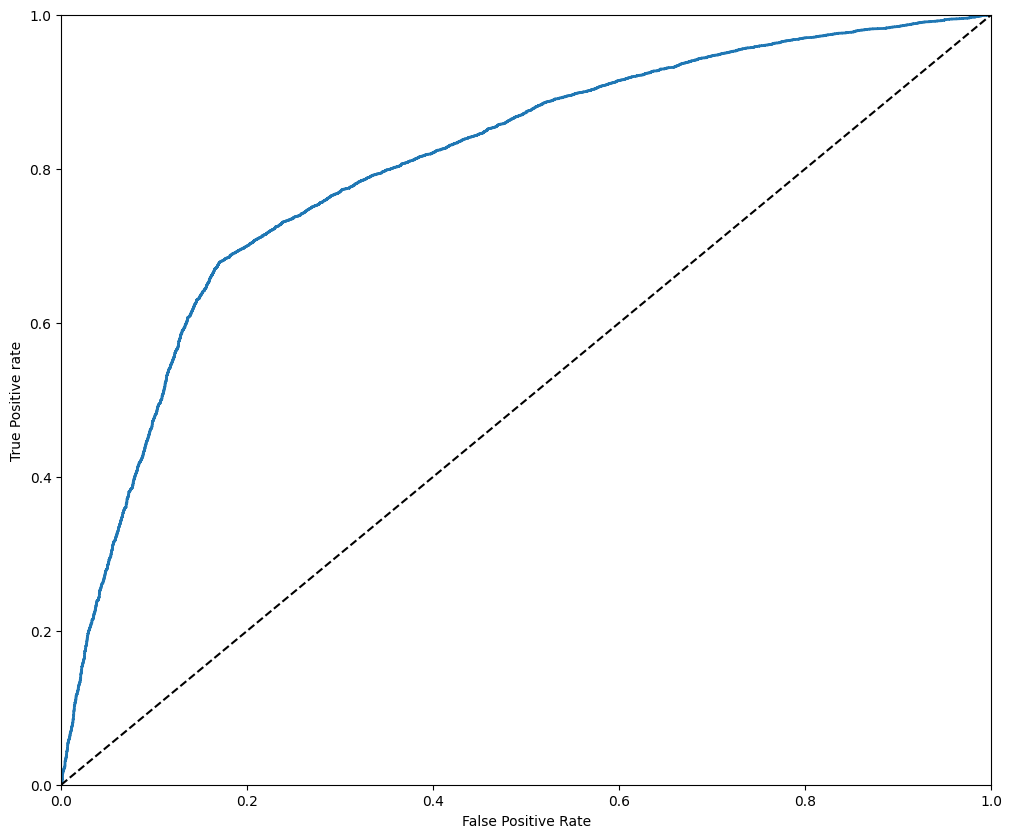

In [65]:
logit_resampled = LogisticRegression(random_state=42, solver="saga", penalty="l1", C=1.0, max_iter=500)
logit_resampled.fit(X_train_rus_scaled, y_train_rus)
logit_resampled_proba_res = logit_resampled.predict_proba(X_train_rus_scaled)
logit_resampled_scores = logit_resampled_proba_res[:,1]
fpr_logit_resampled, tpr_logit_resampled, thresh_logit_resampled = roc_curve(y_train_rus, logit_resampled_scores)
plot_roc_curve(fpr_logit_resampled,tpr_logit_resampled)
print("AUC Score {}".format(roc_auc_score(y_train_rus, logit_resampled_scores)))

## 11. Random Forest Classifier

AUC Score 0.8514800224705517


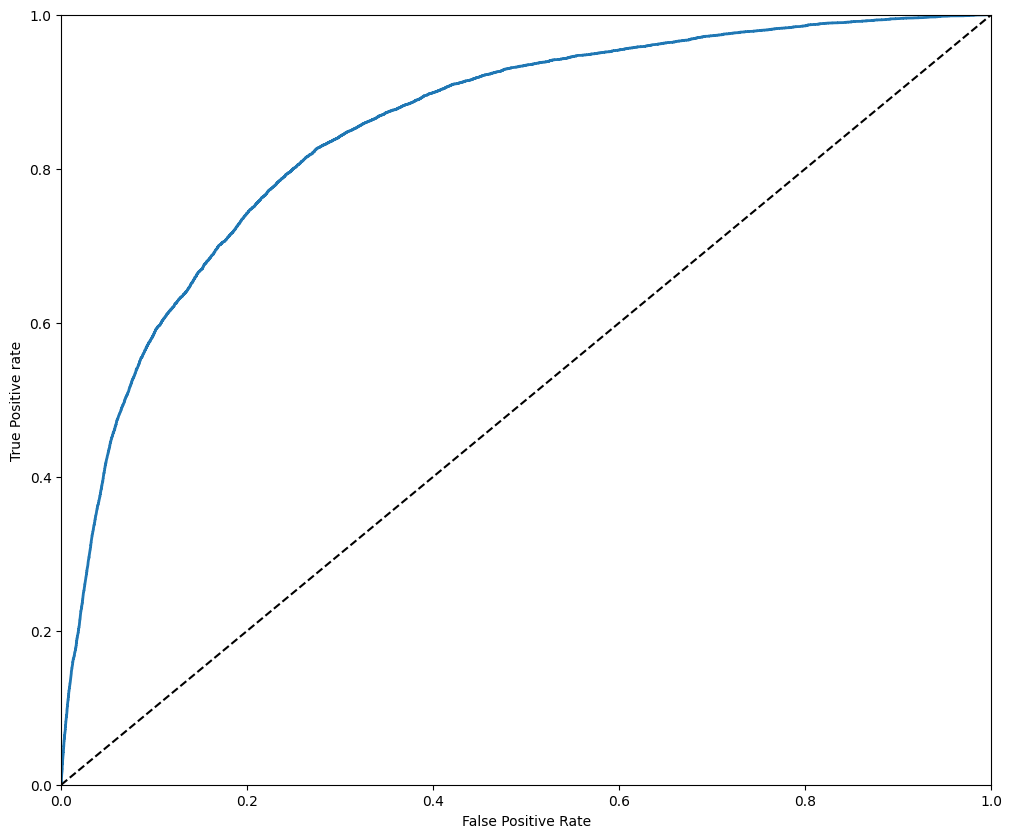

In [66]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
forest = RandomForestClassifier(random_state=42,n_estimators=300, max_depth=5, class_weight="balanced")
forest.fit(X_train,y_train) #Using the original dataset, not the resampled
y_scores_proba = forest.predict_proba(X_train)
y_scores = y_scores_proba[:,1]
fpr, tpr, thresh = roc_curve(y_train, y_scores)
plot_roc_curve(fpr,tpr)
print("AUC Score {}".format(roc_auc_score(y_train,y_scores))) #max_depth=5 .8525 #7 .864 cross .85 #10 .89 cross .85 #9 .88 cross .853 #12 .92 cross .84 Overfit!

AUC Score 0.8531230683783487


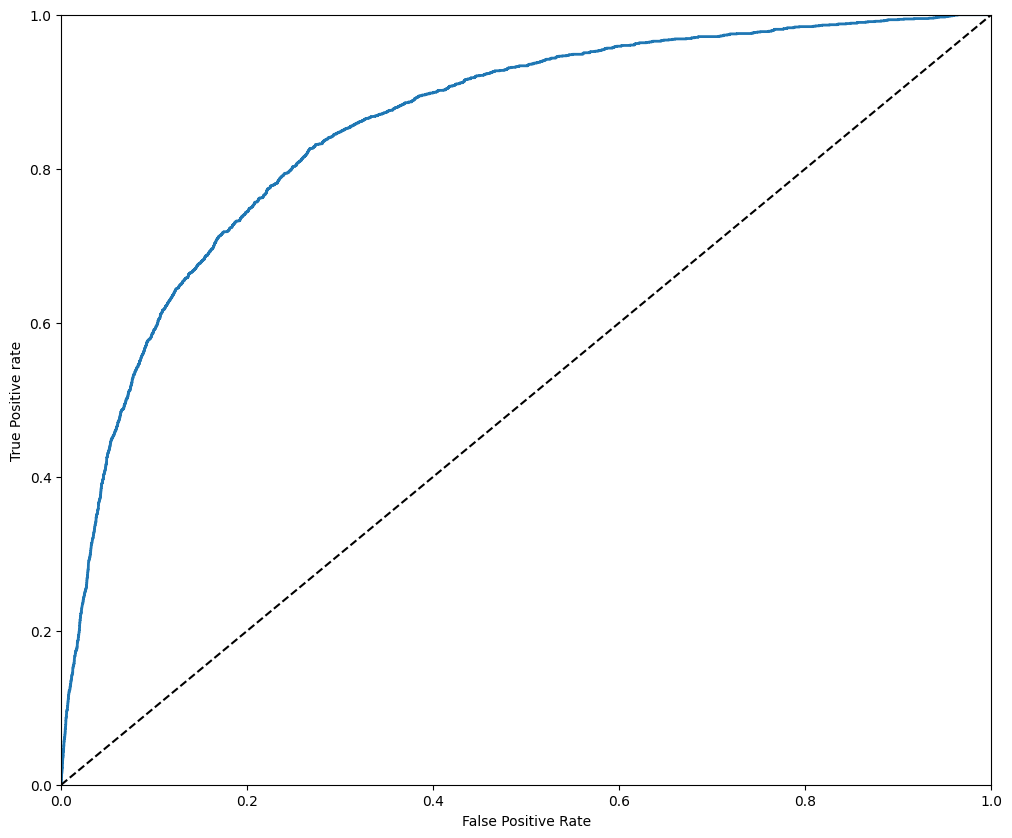

In [67]:
#Let's cross validate
y_val_proba = forest.predict_proba(X_val)
y_scores_val = y_val_proba[:,1]
fpr_val, tpr_val, thresh_val = roc_curve(y_val, y_scores_val)
plot_roc_curve(fpr_val,tpr_val)
print("AUC Score {}".format(roc_auc_score(y_val,y_scores_val)))

Let's see how the random forest classifier treat each of the features, here, the randomforest gives a huge importance for the CombinedDefaulted feature and the RevolvingUtilizationOfUnsecuredLines and almost disgregard the other features in its predictions.

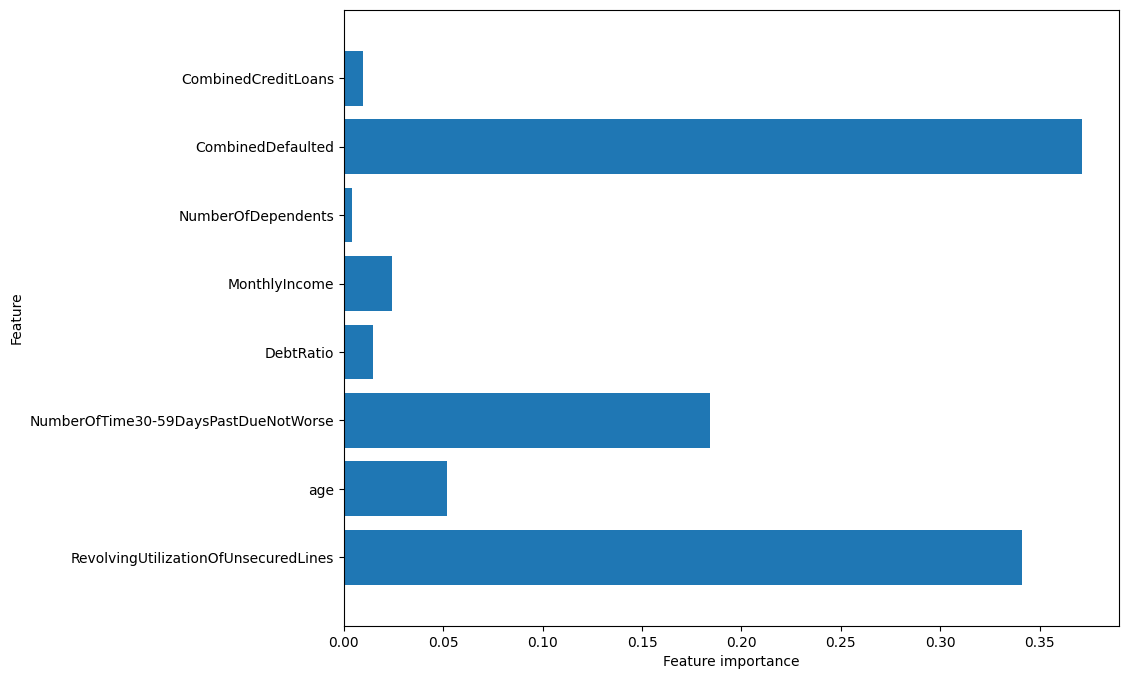

In [68]:
#feature importance
def plot_feature_importances(model):
    plt.figure(figsize=(10,8))
    n_features = X.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), X.columns)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

plot_feature_importances(forest)

Now Let's try GradientBoostingClassifier!

## 12. Gradient Boosting Classifier

AUC Score 0.9334425275312794


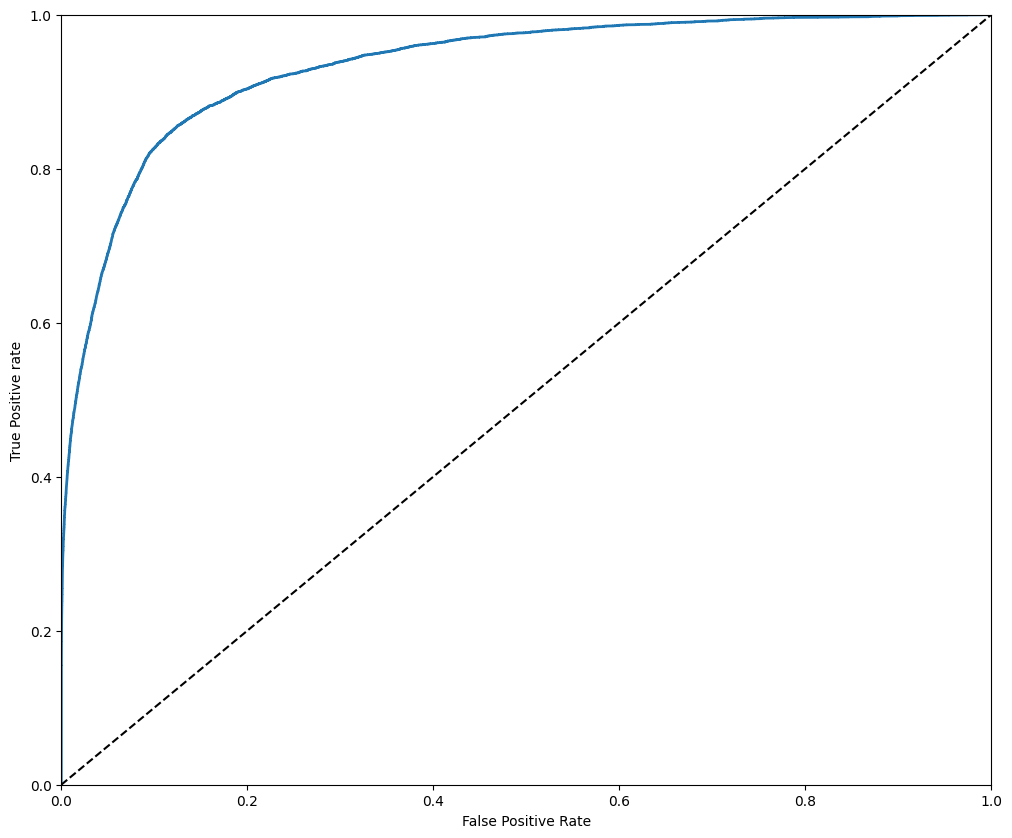

In [69]:
gbc_clf = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=8, random_state=42)
gbc_clf.fit(X_train,y_train)
gbc_clf_proba = gbc_clf.predict_proba(X_train)
gbc_clf_scores = gbc_clf_proba[:,1]
fpr_gbc, tpr_gbc, thresh_gbc = roc_curve(y_train, gbc_clf_scores)
plot_roc_curve(fpr_gbc, tpr_gbc)
print("AUC Score {}".format(roc_auc_score(y_train, gbc_clf_scores)))

In [70]:
#validation
gbc_val_proba = gbc_clf.predict_proba(X_val)
gbc_val_scores = gbc_val_proba[:,1]
print("AUC Score {}".format(roc_auc_score(y_val, gbc_val_scores)))

AUC Score 0.8537320032656347


We are overfitting! Let's try tuning the hyperparameters of our gradient boosting classifier to improve generalization.

In [71]:
gbc_clf_submission = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_samples_leaf=20,
    subsample=0.8,
    random_state=42
)
gbc_clf_submission.fit(X_train,y_train)
gbc_clf_proba = gbc_clf_submission.predict_proba(X_train)
gbc_clf_scores = gbc_clf_proba[:,1]
gbc_val_proba = gbc_clf_submission.predict_proba(X_val)
gbc_val_scores = gbc_val_proba[:,1]
fpr_gbc, tpr_gbc, thresh_gbc = roc_curve(y_train, gbc_clf_scores)
print("AUC Score {}".format(roc_auc_score(y_train, gbc_clf_scores))), print("AUC Score {}".format(roc_auc_score(y_val, gbc_val_scores)))

AUC Score 0.8579765720249617
AUC Score 0.8584720730768187


(None, None)

In [72]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    gbc_clf_submission,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Cross Validation Scores:", scores)
print("Mean ROC-AUC:", scores.mean())

Cross Validation Scores: [0.85398238 0.85407683 0.85766389 0.84965435 0.85728266]
Mean ROC-AUC: 0.8545320226913624


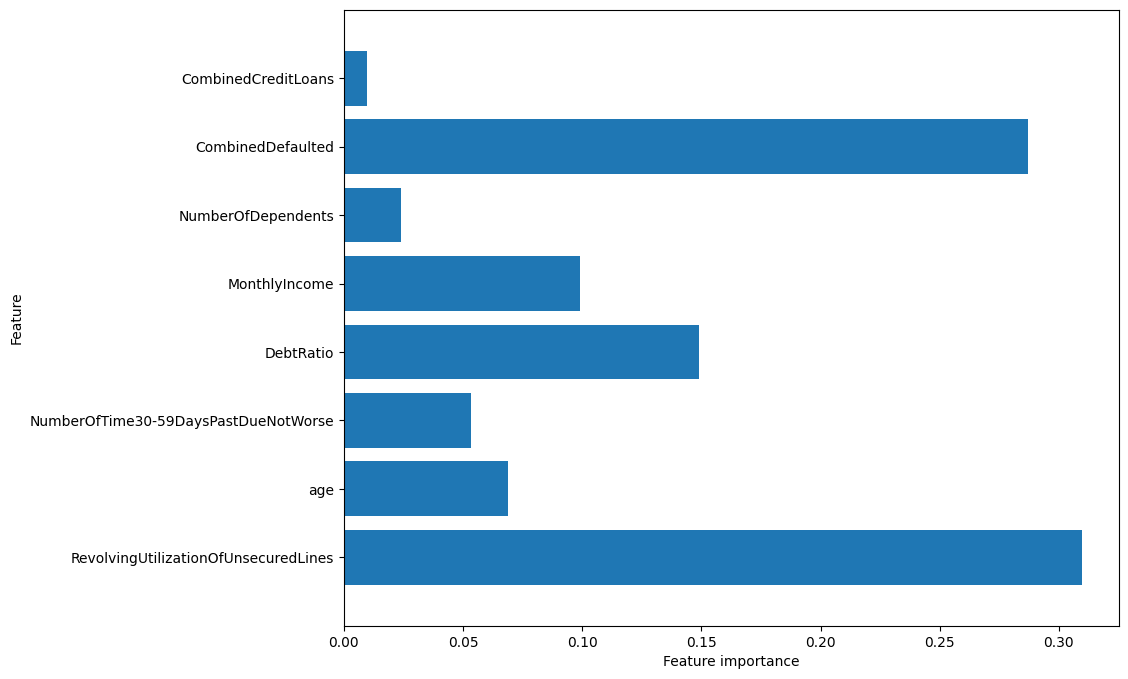

In [73]:
#feature importance
plot_feature_importances(gbc_clf)

Here, the GradientBoostingClassifier gives more emphasis on the RevolvingUtilizationOfUnsecuredLines feature and the DebtRatio, much more equally than the RandonForestClassifier.

In [74]:
from sklearn.metrics import roc_auc_score
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Training AUC": [
        roc_auc_score(y_train, logit_scores),
        roc_auc_score(y_train, y_scores),
        roc_auc_score(y_train, gbc_clf_scores)
    ],

    "Validation AUC": [
        roc_auc_score(y_val, logit_scores_val),
        roc_auc_score(y_val, y_scores_val),
        roc_auc_score(y_val, gbc_val_scores)
    ]
})

comparison

,Model,Training AUC,Validation AUC
0,Logistic Regression,0.801344,0.810269
1,Random Forest,0.851480,0.853123
2,Gradient Boosting,0.857977,0.858472


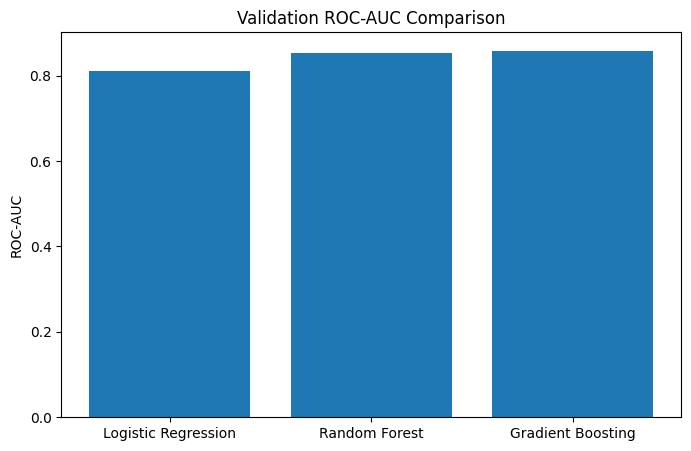

In [75]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"],comparison["Validation AUC"])

plt.title("Validation ROC-AUC Comparison")

plt.ylabel("ROC-AUC")

plt.show()

In [76]:
from sklearn.metrics import classification_report

y_pred = gbc_clf_submission.predict(X_val)

print(classification_report(y_val,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.56      0.10      0.17      2005

    accuracy                           0.93     30000
   macro avg       0.75      0.55      0.57     30000
weighted avg       0.91      0.93      0.91     30000



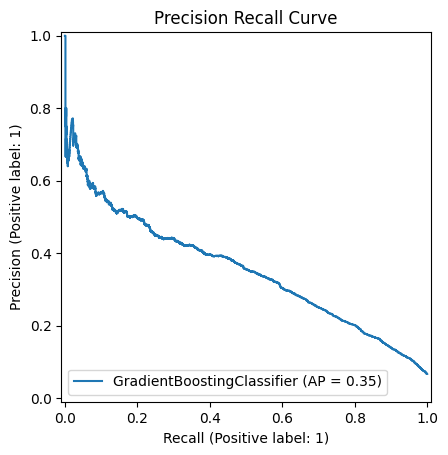

In [77]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(

gbc_clf_submission,

X_val,

y_val

)

plt.title("Precision Recall Curve")

plt.show()

In [78]:
from sklearn.metrics import accuracy_score

from sklearn.metrics import precision_score

from sklearn.metrics import recall_score

from sklearn.metrics import f1_score

print("Accuracy :",accuracy_score(y_val,y_pred))

print("Precision :",precision_score(y_val,y_pred))

print("Recall :",recall_score(y_val,y_pred))

print("F1 Score :",f1_score(y_val,y_pred))

Accuracy : 0.9346333333333333
Precision : 0.5632183908045977
Recall : 0.09775561097256857
F1 Score : 0.1665958351041224


In [79]:
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":gbc_clf_submission.feature_importances_

})

importance = importance.sort_values(

by="Importance",

ascending=False

)

importance

,Feature,Importance
6,CombinedDefaulted,0.515197
0,RevolvingUtilizationOfUnsecuredLines,0.327850
2,NumberOfTime30-59DaysPastDueNotWorse,0.087919
4,MonthlyIncome,0.022519
3,DebtRatio,0.021429
1,age,0.018339
7,CombinedCreditLoans,0.003705
5,NumberOfDependents,0.003041


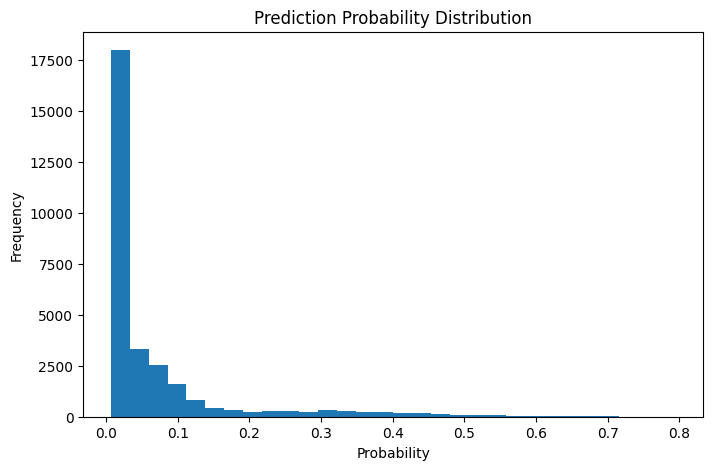

In [80]:
prob = gbc_clf_submission.predict_proba(X_val)[:,1]

plt.figure(figsize=(8,5))

plt.hist(prob,bins=30)

plt.title("Prediction Probability Distribution")

plt.xlabel("Probability")

plt.ylabel("Frequency")

plt.show()

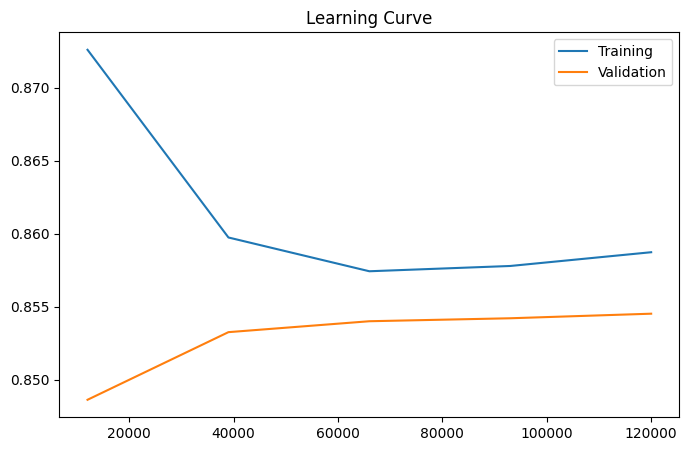

In [81]:
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    gbc_clf_submission,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

plt.figure(figsize=(8,5))

plt.plot(train_sizes,train_scores.mean(axis=1),label="Training")

plt.plot(train_sizes,val_scores.mean(axis=1),label="Validation")

plt.legend()

plt.title("Learning Curve")

plt.show()

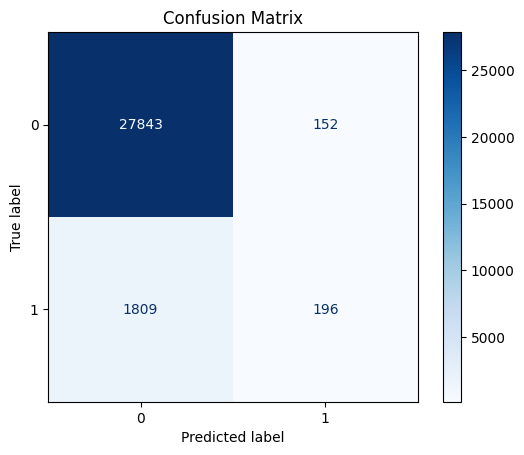

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    gbc_clf_submission,
    X_val,
    y_val,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

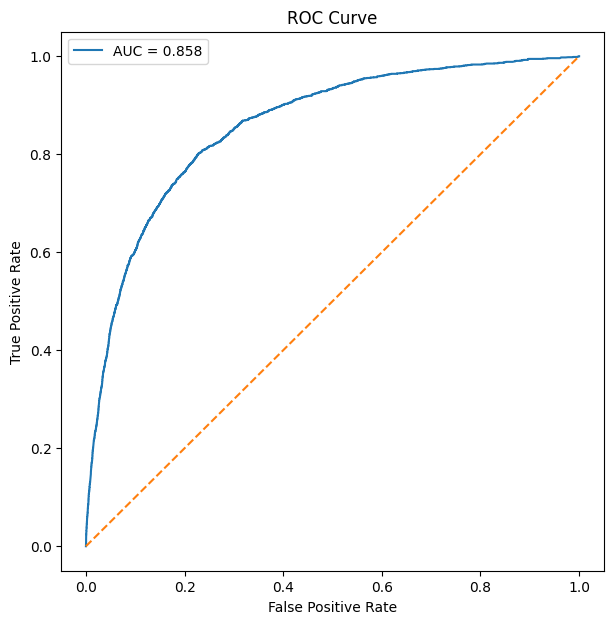

In [83]:
from sklearn.metrics import roc_curve

from sklearn.metrics import roc_auc_score

prob = gbc_clf_submission.predict_proba(X_val)[:,1]

fpr,tpr,_=roc_curve(y_val,prob)

auc=roc_auc_score(y_val,prob)

plt.figure(figsize=(7,7))

plt.plot(fpr,tpr,label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [84]:
from sklearn.metrics import roc_auc_score
import pandas as pd

summary = pd.DataFrame({

    "Algorithm": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "ROC-AUC": [
        roc_auc_score(y_val, logit_scores_val),
        roc_auc_score(y_val, y_scores_val),
        roc_auc_score(y_val, gbc_val_scores)
    ],

    "Status": [
        "Baseline",
        "Good",
        "Best"
    ]

})

summary = summary.round(4)

summary

,Algorithm,ROC-AUC,Status
0,Logistic Regression,0.8103,Baseline
1,Random Forest,0.8531,Good
2,Gradient Boosting,0.8585,Best


## 13. Deploy the model

In [85]:
submission_proba = gbc_clf_submission.predict_proba(X_test)
submission_scores = submission_proba[:,1] #Positive Class

In [86]:
ids = np.arange(1,101504)
submission = pd.DataFrame( {'Id': ids, 'Probability': submission_scores})
submission.to_csv('submission_credit.csv', index=False)

In [87]:
import joblib

# Save the trained model and feature names
artifact = {
    "model": gbc_clf_submission,
    "features": list(gbc_clf_submission.feature_names_in_)
}

joblib.dump(artifact, "credit_risk_analysis_model.pkl")

print("✅ Model saved successfully as 'credit_risk_analysis_model.pkl'")

✅ Model saved successfully as 'credit_risk_analysis_model.pkl'
